# Fly species Identification using Wing Venation Patterns - A Deep Learning Approach

In [1]:
!pip install grad-cam torchcam

## Mount the Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#cp -r ./drive/MyDrive/mh_resnet/fold3/ ./

In [4]:

train_data_dir = '/content/drive/MyDrive/mh_resnet/fold1/train'
test_data_dir = '/content/drive/MyDrive/mh_resnet/fold1/test'

In [5]:
import os

In [6]:
total_images_count = 0
for cls in os.listdir(train_data_dir):
    print(cls, ':', len(os.listdir(train_data_dir + '/' + cls)))
    total_images_count += len(os.listdir(train_data_dir + '/' + cls))
total_images_count

Sy.nudiseta : 43
Ch.megacephala : 42
L.sericata : 43
Ch.bezziana : 42
Ch.albiceps : 43
Ch.albiceps_mutant : 43
C.vicina : 43
A.gressitti : 11
B.karnyi : 16
Ch.nigripes : 8
Ch.rufifacies : 30
Le.alba : 8
Se.princeps : 9
Z.aquila : 15


396

In [7]:
total_images_count = 0
for cls in os.listdir(test_data_dir):
    print(cls, ':', len(os.listdir(test_data_dir + '/' + cls)))
    total_images_count += len(os.listdir(test_data_dir + '/' + cls))
total_images_count

Sy.nudiseta : 19
Ch.megacephala : 17
L.sericata : 20
Se.princeps : 2
Ch.bezziana : 12
Z.aquila : 4
Ch.albiceps : 20
Ch.rufifacies : 7
Ch.nigripes : 2
B.karnyi : 4
Le.alba : 2
Ch.albiceps_mutant : 20
A.gressitti : 2
C.vicina : 20


151

## Import the Dataset Into PyTorch

Use the `ImageFolder` class from `torchvision`.



In [8]:
from torchvision.datasets import ImageFolder

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
from torch.utils.data import Dataset
from PIL import Image
import os

# Create a mapping from species to family
def familyClass(species_name):
  if species_name in ['C.vicina', 'Ch.albiceps', 'Ch.albiceps_mutant', 'Ch.bezziana', 'Ch.megacephala', 'Ch.nigripes', 'Ch.rufifacies', 'L.sericata']:
    return 'Calliphoridae'
  elif species_name in ['B.karnyi', 'Z.aquila', 'Le.alba', 'Se.princeps', 'A.gressitti']:
    return 'Sarcophagidae'
  else:
    return 'Muscidae'


# Define family classes and their mapping globally
global_family_class_names = ['Calliphoridae', 'Sarcophagidae', 'Muscidae']
global_family_class_to_idx = {name: i for i, name in enumerate(global_family_class_names)}

class FamilyImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = global_family_class_names
        self.class_to_idx = global_family_class_to_idx

        # Create a list of (image_path, family_label_idx)
        for species_folder in os.listdir(root_dir):
            species_path = os.path.join(root_dir, species_folder)
            if os.path.isdir(species_path):
                species_name = species_folder
                family_name = familyClass(species_name) # Uses the familyClass function
                if family_name not in self.class_to_idx:
                    raise ValueError(f"Family name '{family_name}' from species '{species_name}' not found in global_family_class_names.")
                family_idx = self.class_to_idx[family_name]
                for img_name in os.listdir(species_path):
                    img_path = os.path.join(species_path, img_name)
                    self.samples.append((img_path, family_idx))
        self.targets = [s[1] for s in self.samples] # Required for stratified split

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB') # Convert to RGB so tt.Grayscale() can consistently work
        if self.transform:
            img = self.transform(img)
        return img, label

In [11]:
import torchvision.transforms as tt

train_dataset = FamilyImageDataset(train_data_dir, tt.Compose([tt.Grayscale(),
                                                        tt.ToTensor()]))
test_dataset = FamilyImageDataset(test_data_dir, tt.Compose([tt.Grayscale(),
                                                      tt.ToTensor()]))

In [12]:
train_dataset.classes

['Calliphoridae', 'Sarcophagidae', 'Muscidae']

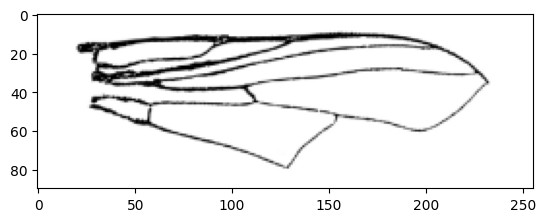

In [13]:
# Example of a training data

img, label = train_dataset[8]
plt.imshow(img.permute((1, 2, 0)), cmap = 'gray')

In [14]:
import torch
random_seed = 42
torch.manual_seed(random_seed)

In [16]:
from sklearn.model_selection import train_test_split

train_ds, valid_ds = train_test_split(train_dataset, test_size = 0.2, random_state=42, stratify=train_dataset.targets)
test_ds = test_dataset

In [17]:
from torch.utils.data import DataLoader

batch_size = 32

train_dl = DataLoader(train_ds,
                      batch_size,
                      shuffle=True,
                      num_workers=2,
                      pin_memory=True)

valid_dl = DataLoader(valid_ds,
                    batch_size,
                    num_workers=2,
                    pin_memory=True)

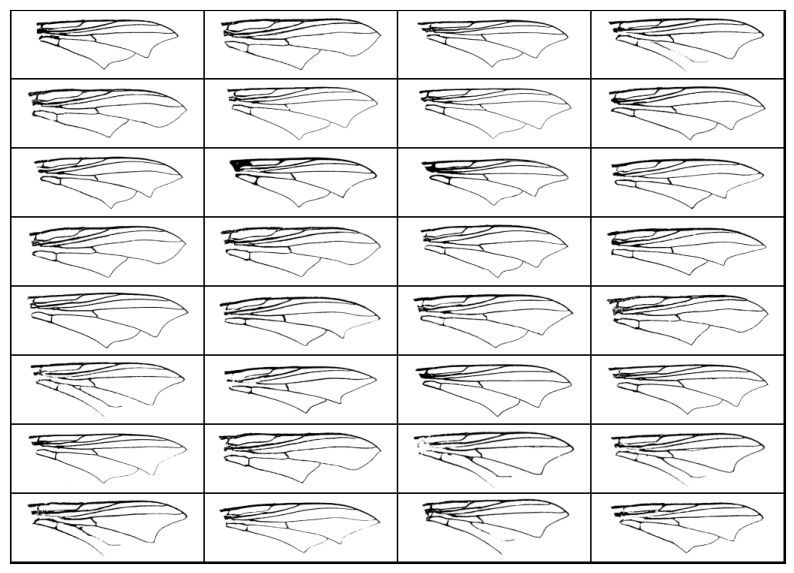

In [18]:
# Example of a batch of training data

from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=4).permute(1, 2, 0))
        break

show_batch(train_dl)

## GPU Setup

In [19]:
import torch

def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)


In [20]:
torch.cuda.is_available()

True

In [21]:
device = get_default_device()

In [22]:
device

device(type='cuda')

In [23]:
img, label = train_dataset[0]

In [24]:
img.device

device(type='cpu')

In [25]:
img_gpu = to_device(img, device)
img_gpu.device

device(type='cuda', index=0)

In [26]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

## Model and Training

In [27]:
weight = torch.tensor([])

In [28]:
import torch.nn as nn
import torch.nn.functional as F

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        "calculate loss for a batch of training data"
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        "calculate loss & accuracy for a batch of validation data"
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [29]:
@torch.no_grad()
def evaluate(model, val_loader):
    """Evaluates the model's performance on the validation set"""
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

## Model

In [30]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channels),
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(ImageClassificationBase):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        # Input: 128 x 3 x 64 x 64
        self.conv1 = conv_block(in_channels, 64) # 128 x 64 x 64 x 64
        self.conv2 = conv_block(64, 128, pool=True) # 128 x 128 x 32 x 32
        self.res1 = nn.Sequential(conv_block(128, 128), # 128 x 128 x 32 x 32
                                  conv_block(128, 128)) # 128 x 128 x 32 x 32

        self.conv3 = conv_block(128, 256, pool=True) # 128 x 256 x 16 x 16
        self.conv4 = conv_block(256, 512, pool=True) # 128 x 512 x 8 x 8
        self.res2 = nn.Sequential(conv_block(512, 512), # 128 x 512 x 8 x 8
                                  conv_block(512, 512)) # 128 x 512 x 8 x 8

        self.classifier = nn.Sequential(nn.AdaptiveMaxPool2d(1), # 128 x 512 x 1 x 1
                                        nn.Flatten(), # 128 x 512
                                        nn.Dropout(0.2),
                                        nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

In [31]:
model = to_device(ResNet9(1, len(global_family_class_names)), device)
model

ResNet9(
  (conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tr

In [32]:
model.conv1[0].weight.device

device(type='cuda', index=0)

Pass one batch of input tensor through the model.

In [33]:
torch.cuda.empty_cache()
for batch in train_dl:
    images, labels = batch
    print('images.shape', images.shape)
    print('images.device', images.device)
    preds = model(images)
    print('preds.shape', preds.shape)
    break

images.shape torch.Size([32, 1, 90, 256])
images.device cuda:0
preds.shape torch.Size([32, 3])


### Training

In [34]:
history = [evaluate(model, valid_dl)]
history

[{'val_loss': 1.12432861328125, 'val_acc': 0.1458333283662796}]

In [35]:
history += fit(40, 0.001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 2.6270, val_loss: 1.4844, val_acc: 0.7396
Epoch [1], train_loss: 0.7968, val_loss: 0.9697, val_acc: 0.7396
Epoch [2], train_loss: 0.6952, val_loss: 0.7954, val_acc: 0.7396
Epoch [3], train_loss: 0.5373, val_loss: 0.7309, val_acc: 0.9375
Epoch [4], train_loss: 0.3757, val_loss: 0.6326, val_acc: 0.7188
Epoch [5], train_loss: 0.2449, val_loss: 0.6734, val_acc: 0.7188
Epoch [6], train_loss: 0.2269, val_loss: 0.1389, val_acc: 0.9792
Epoch [7], train_loss: 0.1296, val_loss: 1.5736, val_acc: 0.2083
Epoch [8], train_loss: 0.1163, val_loss: 0.1703, val_acc: 0.9375
Epoch [9], train_loss: 0.0528, val_loss: 0.0422, val_acc: 0.9896
Epoch [10], train_loss: 0.0492, val_loss: 0.0197, val_acc: 0.9896
Epoch [11], train_loss: 0.0263, val_loss: 0.0102, val_acc: 1.0000
Epoch [12], train_loss: 0.0251, val_loss: 0.0306, val_acc: 0.9896
Epoch [13], train_loss: 0.0171, val_loss: 0.0064, val_acc: 1.0000
Epoch [14], train_loss: 0.0118, val_loss: 0.0071, val_acc: 1.0000
Epoch [15], train_lo

In [36]:
history += fit(40, 0.0001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 0.0242, val_loss: 0.0104, val_acc: 1.0000
Epoch [1], train_loss: 0.0030, val_loss: 0.0027, val_acc: 1.0000
Epoch [2], train_loss: 0.0096, val_loss: 0.0015, val_acc: 1.0000
Epoch [3], train_loss: 0.0095, val_loss: 0.0058, val_acc: 1.0000
Epoch [4], train_loss: 0.0056, val_loss: 0.0009, val_acc: 1.0000
Epoch [5], train_loss: 0.0021, val_loss: 0.0029, val_acc: 1.0000
Epoch [6], train_loss: 0.0017, val_loss: 0.0008, val_acc: 1.0000
Epoch [7], train_loss: 0.0007, val_loss: 0.0023, val_acc: 1.0000
Epoch [8], train_loss: 0.0004, val_loss: 0.0006, val_acc: 1.0000
Epoch [9], train_loss: 0.0005, val_loss: 0.0003, val_acc: 1.0000
Epoch [10], train_loss: 0.0054, val_loss: 0.0040, val_acc: 1.0000
Epoch [11], train_loss: 0.0052, val_loss: 0.0003, val_acc: 1.0000
Epoch [12], train_loss: 0.0028, val_loss: 0.0020, val_acc: 1.0000
Epoch [13], train_loss: 0.0005, val_loss: 0.0008, val_acc: 1.0000
Epoch [14], train_loss: 0.0004, val_loss: 0.0004, val_acc: 1.0000
Epoch [15], train_lo

In [37]:
history += fit(40, 0.00001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [1], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [2], train_loss: 0.0002, val_loss: 0.0000, val_acc: 1.0000
Epoch [3], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [4], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [5], train_loss: 0.0001, val_loss: 0.0000, val_acc: 1.0000
Epoch [6], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [7], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [8], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [9], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [10], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [11], train_loss: 0.0001, val_loss: 0.0000, val_acc: 1.0000
Epoch [12], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [13], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [14], train_loss: 0.0000, val_loss: 0.0000, val_acc: 1.0000
Epoch [15], train_lo

In [38]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

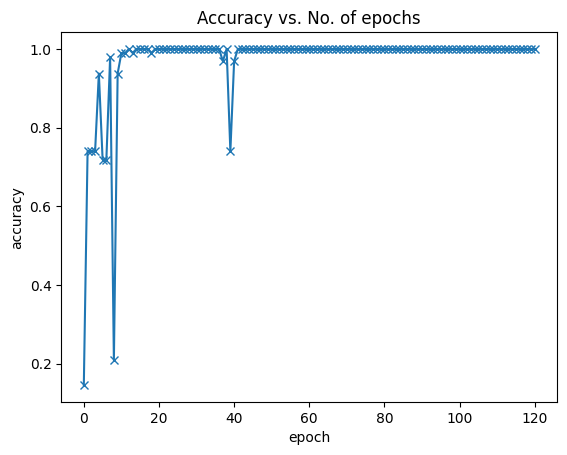

In [39]:
plot_accuracies(history)

In [40]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

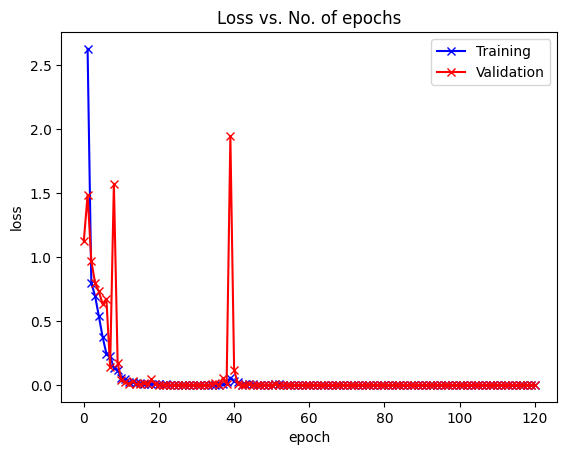

In [41]:
plot_losses(history)

In [42]:
model

ResNet9(
  (conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tr

In [43]:
torch.save(model.state_dict(), './model')

### Testing

In [44]:
def predict_image(img, model, classes):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return classes[preds[0].item()]

In [45]:
import pandas as pd
import os # Make sure os is imported for os.path.basename

df = pd.DataFrame(columns=['Target', 'Prediction', 'TargetFamily', 'PredictionFamily'])

number_of_test_image = len(test_ds)

# Prepare lists to build the DataFrame efficiently
target_list = []
prediction_list = []
target_family_list = []
prediction_family_list = []
target_index_list = []

for i in range(number_of_test_image):
  img, label = test_ds[i]
  pred_class_name = predict_image(img, model, test_dataset.classes)

  true_class_name = test_dataset.classes[label]
  img_path_full, _ = test_dataset.samples[i] # Get full path from samples

  target_list.append(true_class_name)
  prediction_list.append(pred_class_name)
  target_family_list.append(true_class_name) # Since classes are now families
  prediction_family_list.append(pred_class_name) # Since predictions are now families
  target_index_list.append(os.path.basename(img_path_full))


df['Target'] = target_list
df['Prediction'] = prediction_list
df['TargetFamily'] = target_family_list
df['PredictionFamily'] = prediction_family_list
df['TargetIndex'] = target_index_list
df['Match'] = (df['Target'] == df['Prediction']).astype(int)
df['MatchFamily'] = (df['TargetFamily'] == df['PredictionFamily']).astype(int)

df

,Target,Prediction,TargetFamily,PredictionFamily,TargetIndex,Match,MatchFamily
0,Muscidae,Muscidae,Muscidae,Muscidae,S.nudiseta.12.png,1,1
1,Muscidae,Muscidae,Muscidae,Muscidae,S.nudiseta.2.png,1,1
2,Muscidae,Muscidae,Muscidae,Muscidae,S.nudiseta.21.png,1,1
3,Muscidae,Muscidae,Muscidae,Muscidae,S.nudiseta.28.png,1,1
4,Muscidae,Muscidae,Muscidae,Muscidae,S.nudiseta.30.png,1,1
...,...,...,...,...,...,...,...
146,Calliphoridae,Calliphoridae,Calliphoridae,Calliphoridae,C.vicina.75.png,1,1
147,Calliphoridae,Calliphoridae,Calliphoridae,Calliphoridae,C.vicina.85.png,1,1
148,Calliphoridae,Calliphoridae,Calliphoridae,Calliphoridae,C.vicina.95.png,1,1
149,Calliphoridae,Calliphoridae,Calliphoridae,Calliphoridae,C.vicina.97.png,1,1


In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os
import pandas as pd

# Create a DataLoader for the test set to perform evaluation on all test images
test_dl = DeviceDataLoader(DataLoader(test_dataset, batch_size*2), device)

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            images, labels = batch
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

# Get predictions on the full test set
y_pred_family_idx, y_true_family_idx = get_predictions(model, test_dl)

# Get class names (which are now family names)
family_class_names = test_dataset.classes

# Map indices back to family names for clarity in report
y_pred_family = [family_class_names[idx] for idx in y_pred_family_idx]
y_true_family = [family_class_names[idx] for idx in y_true_family_idx]

# --- Analyze incorrect predictions ---
# --- Create a DataFrame with predictions ---

# Create a list of dictionaries with all the required information
predictions_list = []
for i in range(len(y_true_family_idx)):
    img_path, _ = test_dataset.samples[i]

    predictions_list.append({
        'sample_name': os.path.basename(img_path),
        'TargetFamily': y_true_family[i],
        'PredictionFamily': y_pred_family[i],
        'MatchFamily': y_true_family[i] == y_pred_family[i]
    })

# Create the DataFrame
test_family_df = pd.DataFrame(predictions_list)

# Display the wrongly predicted rows
wrong_predictions_family = test_family_df[test_family_df['MatchFamily'] == False]
print("Wrongly predicted rows (Family Level):")
display(wrong_predictions_family[['sample_name', 'TargetFamily','PredictionFamily']])


# --- Performance Metrics ---
def calculate_metrics(y_true, y_pred, class_names, labels=None):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0, labels=labels)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Handle cases where cm might be empty or a single class
    if cm.shape[0] == 0:
        return report, np.array([]), np.array([]), np.array([])

    sensitivity = np.diag(cm) / np.sum(cm, axis=1)
    # Replace NaNs (e.g., if a class has no true instances) with 0 or a sensible value
    sensitivity[np.isnan(sensitivity)] = 0

    specificity = []
    for i in range(len(class_names)):
        true_negatives = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        false_positives = np.sum(cm[:, i]) - cm[i, i]
        if (true_negatives + false_positives) == 0:
            specificity.append(1.0) # Avoid division by zero, assuming perfect specificity if no FPs or TNs
        else:
            specificity.append(true_negatives / (true_negatives + false_positives))

    balanced_accuracy = (sensitivity + np.array(specificity)) / 2

    return report, sensitivity, specificity, balanced_accuracy


print("\n--- Family Level Metrics ---")
report_family, sensitivity_family, specificity_family, balanced_accuracy_family = calculate_metrics(
    y_true_family, y_pred_family, family_class_names, labels=family_class_names
)

print(classification_report(y_true_family, y_pred_family, target_names=family_class_names, zero_division=0))
avg_sensitivity_family = np.mean(sensitivity_family)
avg_specificity_family = np.mean(specificity_family)
avg_balanced_accuracy_family = np.mean(balanced_accuracy_family)
print(f"Averaged Sensitivity (Recall): {avg_sensitivity_family:.4f}")
print(f"Averaged Specificity: {avg_specificity_family:.4f}")
print(f"Averaged Balanced Accuracy: {avg_balanced_accuracy_family:.4f}")
print("Test set accuracy (Family Level) = {:.2f}% ({} / {})".format(
    test_family_df['MatchFamily'].sum() / len(test_family_df) * 100, test_family_df['MatchFamily'].sum(), len(test_family_df)
))


Wrongly predicted rows (Family Level):


,sample_name,TargetFamily,PredictionFamily



--- Family Level Metrics ---
               precision    recall  f1-score   support

Calliphoridae       1.00      1.00      1.00       118
Sarcophagidae       1.00      1.00      1.00        19
     Muscidae       1.00      1.00      1.00        14

     accuracy                           1.00       151
    macro avg       1.00      1.00      1.00       151
 weighted avg       1.00      1.00      1.00       151

Averaged Sensitivity (Recall): 1.0000
Averaged Specificity: 1.0000
Averaged Balanced Accuracy: 1.0000
Test set accuracy (Family Level) = 100.00% (151 / 151)


In [47]:
# Test set accuracy (Family Level)
print("Test set accuracy (Family Level) = " + str(round(test_family_df['MatchFamily'].sum() / number_of_test_image * 100, 2)) + "% (" +
      str(test_family_df['MatchFamily'].sum()) + "/" + str(number_of_test_image) + ")")

# Precision, Recall & F1 Score for each family
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import numpy as np

def familyLevelMetric(family_name):
  y_true_binary = []
  y_pred_binary = []
  for item in test_family_df['TargetFamily']:
    if item == family_name:
      y_true_binary.append(1)
    else:
      y_true_binary.append(0)

  for item in test_family_df['PredictionFamily']:
    if item == family_name:
      y_pred_binary.append(1)
    else:
      y_pred_binary.append(0)
  return (y_true_binary, y_pred_binary)

def precisionRecallF1Df(family_name):
  # Ensure precision, recall, f1 are calculated only if the family exists in predictions or targets
  if __builtins__.sum(familyLevelMetric(family_name)[0]) == 0 and __builtins__.sum(familyLevelMetric(family_name)[1]) == 0:
    return pd.DataFrame(np.array([family_name, 0.0, 0.0, 0.0]).reshape(1,-1), columns = ['Family', 'Precision', 'Recall', 'F1_score'])

  precision = round(precision_score(familyLevelMetric(family_name)[0], familyLevelMetric(family_name)[1], zero_division=0), 2)
  recall = round(recall_score(familyLevelMetric(family_name)[0], familyLevelMetric(family_name)[1], zero_division=0), 2)

  # Handle cases where precision + recall is zero to avoid division by zero for F1
  if (precision + recall) == 0:
      f1 = 0.0
  else:
      f1 = round((2 * precision * recall) / (precision + recall), 2)

  return pd.DataFrame(np.array([family_name, precision, recall, f1]).reshape(1,-1), columns = ['Family', 'Precision', 'Recall', 'F1_score'])

familyLevelMetricDf = pd.DataFrame(columns=['Family', 'Precision', 'Recall', 'F1_score'])

for family_name in test_family_df['TargetFamily'].unique():
  new_row = precisionRecallF1Df(family_name)
  familyLevelMetricDf = pd.concat([familyLevelMetricDf, new_row])

print('Precision, Recall & F1 score for each family')
print(familyLevelMetricDf)

# List of wrong predictions
wrongPredictionDf = test_family_df[test_family_df['TargetFamily'] != test_family_df['PredictionFamily']]
print('List of wrong predictions (Family Level)')
print(wrongPredictionDf[['TargetFamily', 'PredictionFamily', 'sample_name']])


Test set accuracy (Family Level) = 100.0% (151/151)
Precision, Recall & F1 score for each family
          Family Precision Recall F1_score
0       Muscidae       1.0    1.0      1.0
0  Calliphoridae       1.0    1.0      1.0
0  Sarcophagidae       1.0    1.0      1.0
List of wrong predictions (Family Level)
Empty DataFrame
Columns: [TargetFamily, PredictionFamily, sample_name]
Index: []


## Confusion matrix

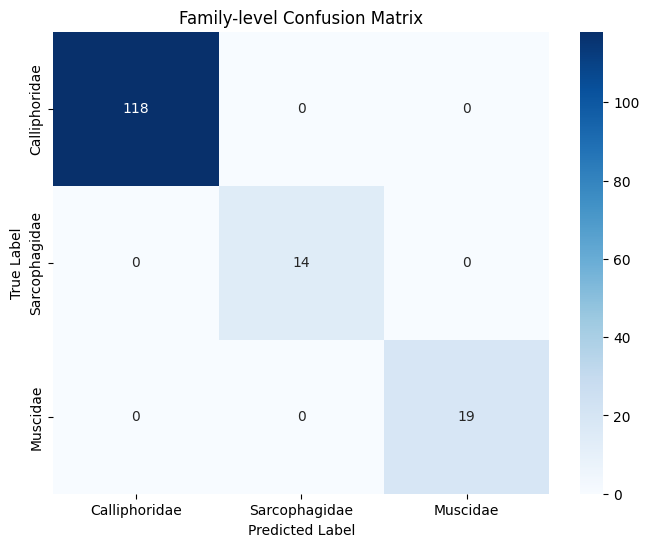

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(8,6)) # Increased figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Family-level confusion matrix
cm_family = confusion_matrix(y_true_family, y_pred_family, labels=family_class_names)
plot_confusion_matrix(cm_family, family_class_names, title='Family-level Confusion Matrix')


In [49]:
# This cell is no longer needed as species-level confusion matrix is not relevant now
# and family-level confusion matrix is plotted in the previous cell.

### Model explainability using Grad-CAM


In [50]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torchvision.transforms as tt

test_transform = tt.Compose([tt.Grayscale(), tt.ToTensor()])
folder_path = "/content/drive/MyDrive/mh_resnet/fold1/test"

file_name = []
for i in os.listdir(folder_path):
    species_name = i
    for j in os.listdir(os.path.join(folder_path,species_name)):
      file_name.append(os.path.join(folder_path, species_name, j))

In [52]:
# Get model explainability using gradcam
import torchcam
from torchcam.utils import overlay_mask
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image # Import show_cam_on_image

#output_base_dir = "/content/drive/MyDrive/mh_resnet/gradcam/fold4" # Use a new output directory
output_base_dir = "/content/drive/MyDrive/mh_resnet_results/fold1_gradcam_output_enhanced"


for img_path in file_name:
  img_pil = Image.open(img_path)
  img_np = np.array(img_pil.convert('RGB')) # Convert to numpy array in RGB for show_cam_on_image

  input_tensor = test_transform(img_pil).unsqueeze(0).to(device)

  # Grad-CAM setup
  target_layers = [model.res2[-1]]
  cam = GradCAM(model=model, target_layers=target_layers)
  grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

  # Use show_cam_on_image for better visualization control
  # You can experiment with different colormaps like 'jet', 'hot', etc.
  # Use a higher threshold or different post-processing for more contrast if needed.
  cam_image = show_cam_on_image(img_np.astype(np.float32) / 255., grayscale_cam, use_rgb=True)

  # Convert back to PIL Image for saving
  result = Image.fromarray(cam_image)


  # Construct the output path
  relative_path = os.path.relpath(img_path, folder_path)
  output_path = os.path.join(output_base_dir, relative_path)

  # Create directories if they don't exist
  output_dir = os.path.dirname(output_path)
  if not os.path.exists(output_dir):
    os.makedirs(output_dir)

  # Save the result
  result.save(output_path)

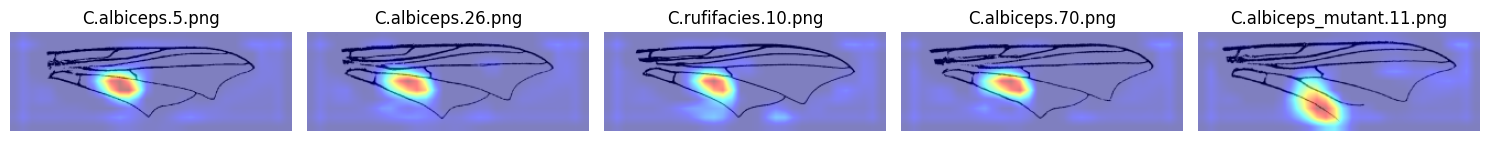

In [53]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import random

#output_base_dir = "/content/drive/MyDrive/mh_resnet/gradcam/fold4"
output_base_dir = "/content/drive/MyDrive/mh_resnet_results/fold1_gradcam_output_enhanced"

# Get a list of all generated Grad-CAM image files
gradcam_files = []
for root, _, files in os.walk(output_base_dir):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')): # Add other image formats if needed
            gradcam_files.append(os.path.join(root, file))

# Display a few random Grad-CAM images
num_images_to_display = 5
if len(gradcam_files) > 0:
    images_to_display = random.sample(gradcam_files, min(num_images_to_display, len(gradcam_files)))

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(images_to_display):
        img = Image.open(img_path)
        plt.subplot(1, num_images_to_display, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No Grad-CAM images found in the output directory.")